In [1]:
import sys
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from utils import * #only needed for xgboost

from friedman1 import *
import friedman_config as c


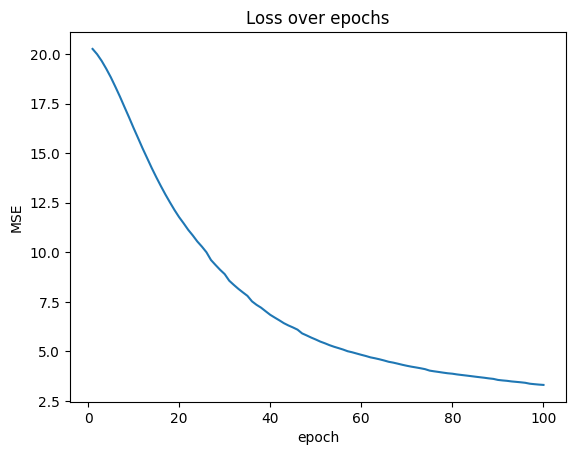

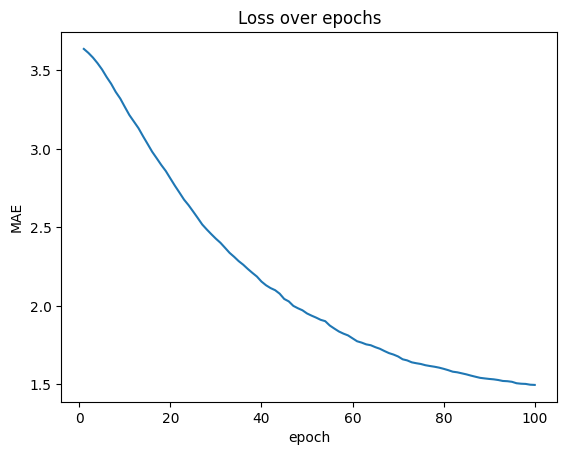

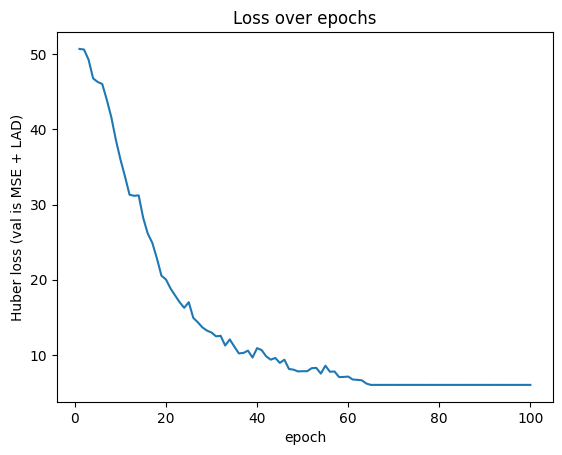

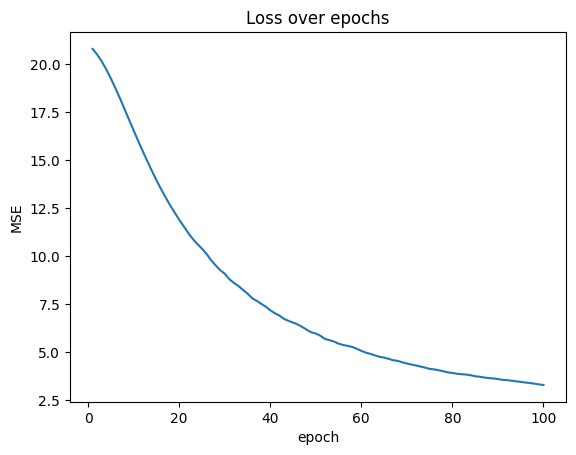

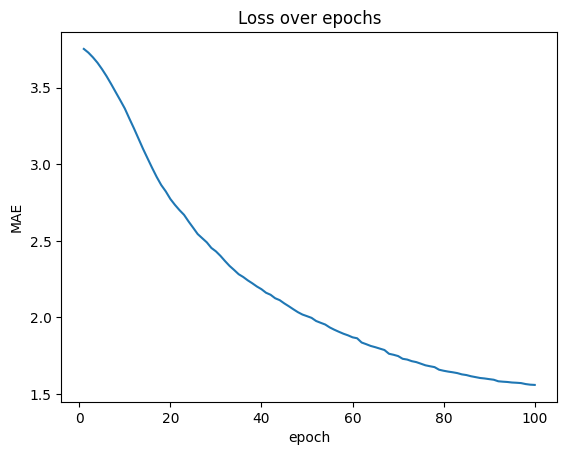

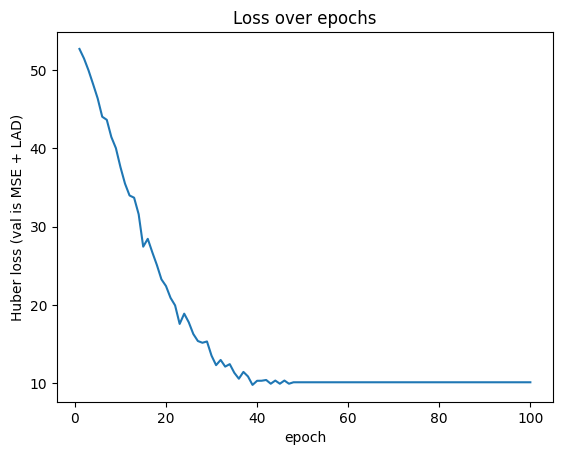

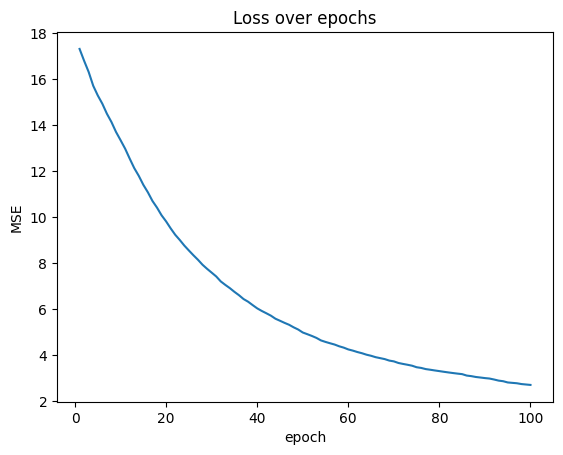

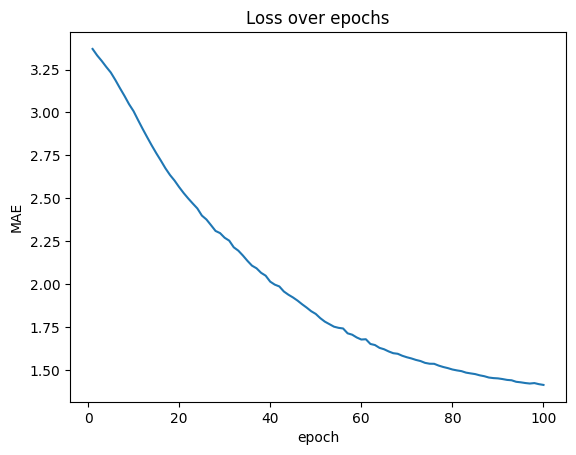

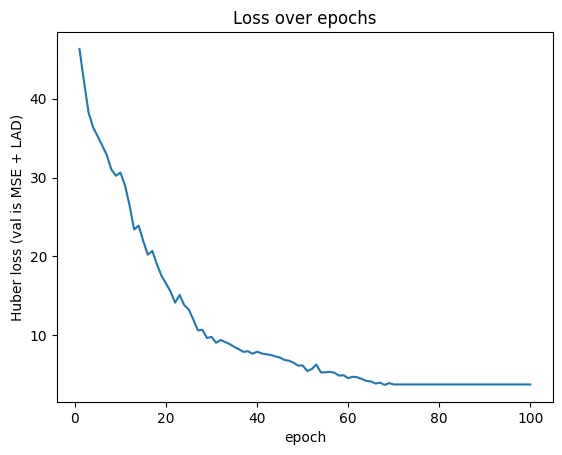

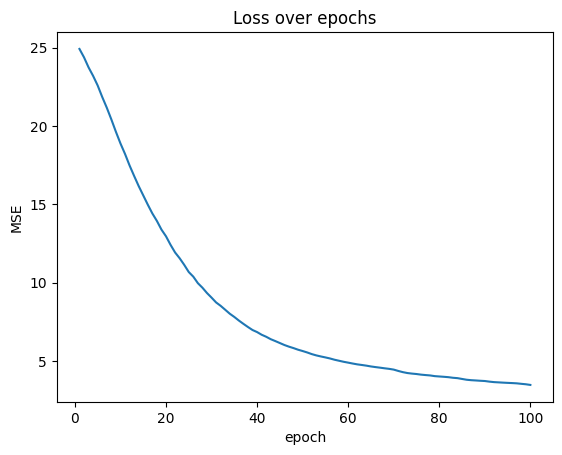

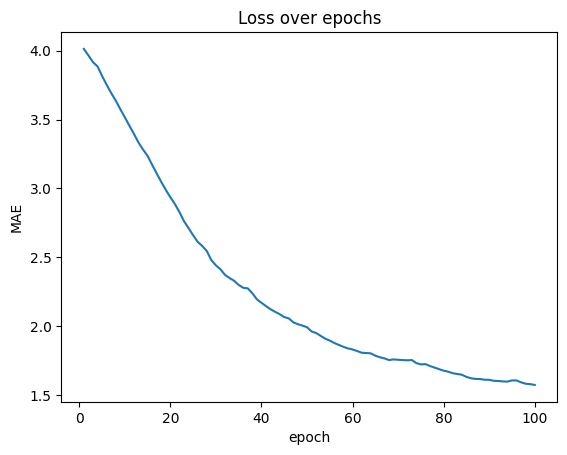

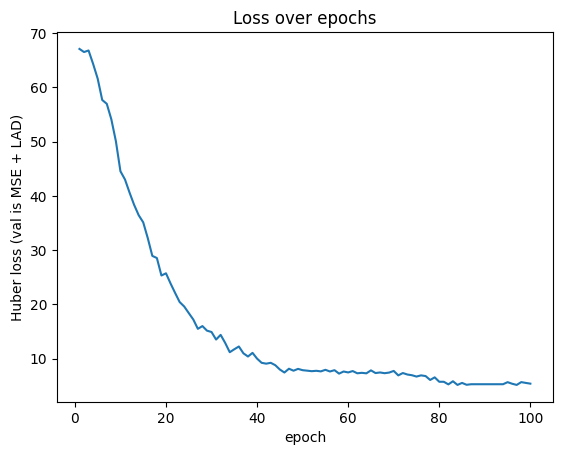

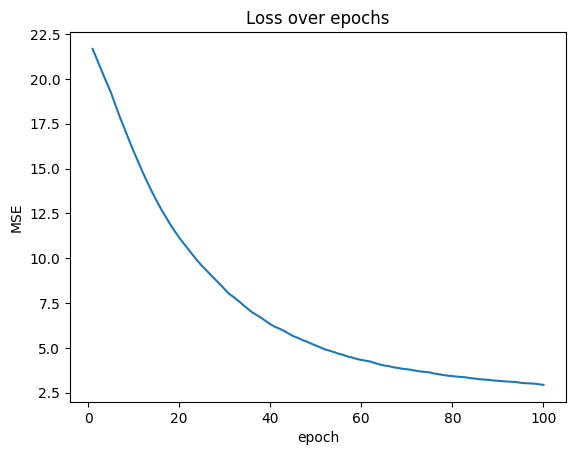

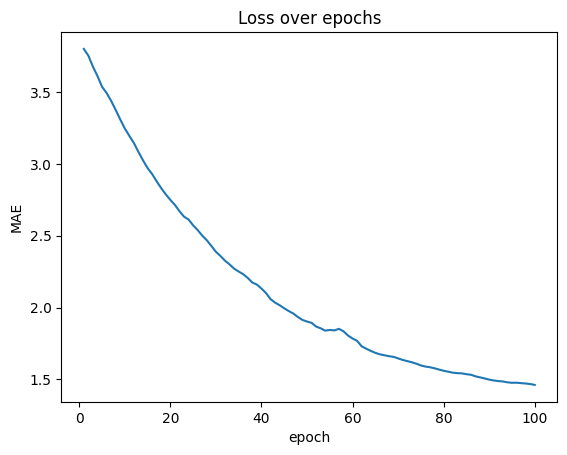

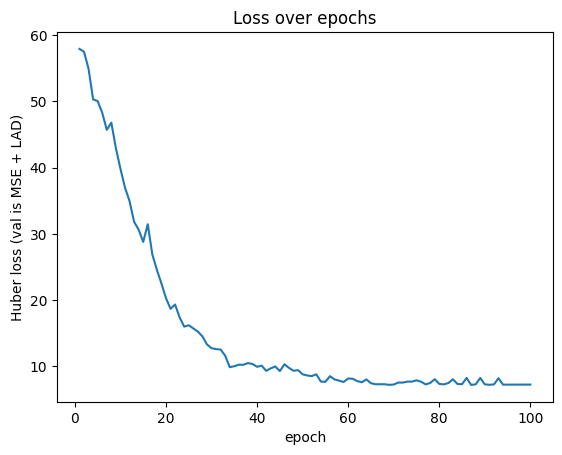

In [2]:
#Run experiments for gaussian distributed errors (target_instances = 200, d = 6)
#We already have the experiments for LS in from before so only LAD is needed

df = pd.DataFrame(columns = ['seed', 'method', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0', 'epochs',
                                                          'val_rmse', 'val_mae', 'rmse', 'mae'])




for seed in c.seed_list:

    
    X_target_test, y_target_test = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(n_samples=200, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set
    X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'gaussian',
                                                    n_features=10, d=6, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
    for config in c.param_grid_LSTransferTreeBoost:
        v, source_tree_size, target_tree_size, k, m_0, epochs = config


        #LS already done before

        
        method = f'LSTransferTreeBoost'
        fiter = LSTransferTreeBoost(epochs=epochs, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, early_stopping_rounds=8, show_curves=True)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, epochs,
                                                          val_rmse, val_mae, rmse, mae]
        

        method = f'LADTransferTreeBoost'
        fiter = LADTransferTreeBoost(epochs=epochs, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, early_stopping_rounds=8, show_curves=True)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, epochs, 
                                                          val_rmse, val_mae, rmse, mae]
        df.to_csv('results/200_gaussian_6.csv')

        method = f'MTransferTreeBoost'
        fiter = MTransferTreeBoost(epochs=epochs, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, early_stopping_rounds=8, show_curves=True)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, epochs, 
                                                          val_rmse, val_mae, rmse, mae]
        df.to_csv('results/200_gaussian_6.csv')


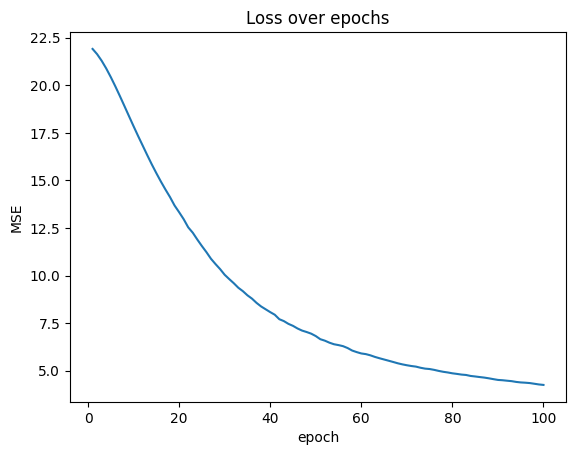

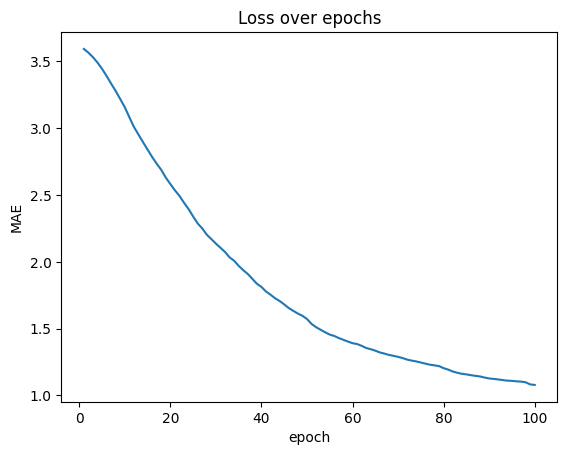

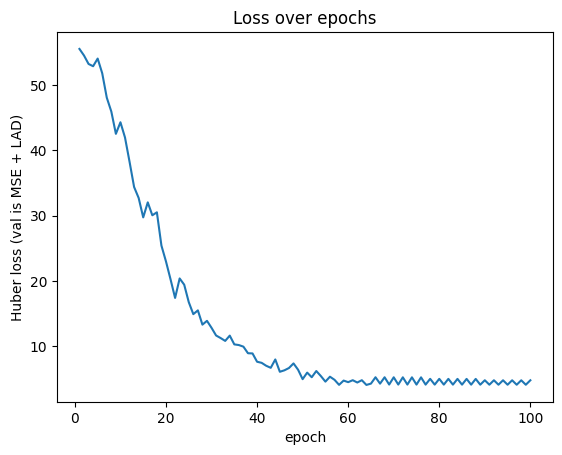

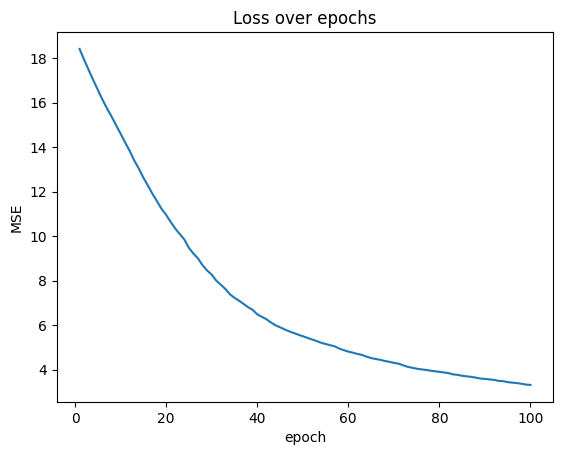

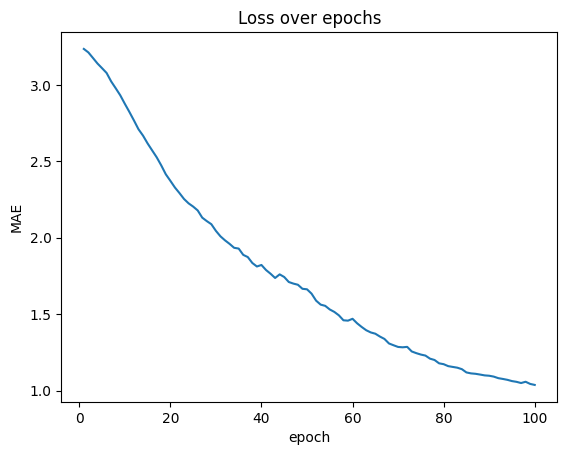

KeyboardInterrupt: 

In [3]:
#For some reason we changed the seed list here, but it does not matter as we now compare using slash distribution
seed_list = [2,3,4,5,6]

df = pd.DataFrame(columns = ['seed', 'method',
                                   'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0', 'epochs',
                                     'val_rmse', 'val_mae', 'rmse', 'mae'])



for seed in seed_list:

    
    X_target_test, y_target_test = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'slash', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'slash', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(n_samples=200, add_noise = True, noise_distribution = 'slash', n_features=10, random_seed=seed) #add noise to train set
    X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'slash',
                                                    n_features=10, d=6, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
    for config in c.param_grid_LSTransferTreeBoost:
        v, source_tree_size, target_tree_size, k, m_0, epochs = config


        #Test for all methods as we do not have results for slash errors
        
        method = f'LSTransferTreeBoost'
        fiter = LSTransferTreeBoost(epochs=epochs, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, early_stopping_rounds=8, show_curves=True)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, epochs,
                            val_rmse, val_mae, rmse, mae]
        

        method = f'LADTransferTreeBoost'
        fiter = LADTransferTreeBoost(epochs=epochs, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, early_stopping_rounds=8, show_curves=True)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, epochs,
                            val_rmse, val_mae, rmse, mae]
        df.to_csv('results/200_slash_6.csv')

        method = f'MTransferTreeBoost'
        fiter = MTransferTreeBoost(epochs=epochs, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, early_stopping_rounds=8, show_curves=True)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, epochs,
                            val_rmse, val_mae, rmse, mae]
        df.to_csv('results/200_slash_6.csv')